# Step 5 — Parameter Tuning: Tuning de Hiperparâmetros

## Objetivo

Otimizar os hiperparâmetros dos dois modelos mais promissores identificados em `05_treinamento.ipynb` — **Random Forest** e **Regressão Logística** — usando `GridSearchCV` com 5-fold cross-validation.

A métrica de otimização é o **Recall macro**, pois o problema envolve 3 classes clínicas e o custo de um Falso Negativo em qualquer uma delas é alto — especialmente para `pneumonia`.

| Step | Notebook | Status |
|---|---|---|
| 4 — Train the Model | `05_treinamento.ipynb` | ✅ Concluído |
| **5 — Parameter Tuning** | **`06_tuning.ipynb`** | **← Este notebook** |
| 6 — Evaluation & Testing | `07_avaliacao_shap.ipynb` | ⬜ Próximo |

> **O que são hiperparâmetros?** São configurações do algoritmo definidas *antes* do treino — como `n_estimators` (número de árvores no Random Forest) ou `C` (força da regularização na Regressão Logística). Eles não são aprendidos dos dados; são decisões de projeto que impactam diretamente a qualidade do modelo.

> **Por que GridSearchCV?** Testa todas as combinações possíveis dos hiperparâmetros definidos em `param_grid`, avaliando cada combinação via cross-validation (5 folds). Garante que a escolha do melhor hiperparâmetro seja feita sem usar o conjunto de teste.

> **Nota sobre o pré-processamento:** Os dados nos CSVs (`X_train.csv`, `X_val.csv`) já estão pré-processados — as features numéricas `oxygen_saturation` e `wbc_count` foram normalizadas pelo `StandardScaler` no `03_preprocessamento.ipynb` e os valores escalonados foram salvos diretamente nos arquivos CSV. Não é necessário re-aplicar o scaler aqui.

In [1]:
import os
import pickle
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    recall_score,
    f1_score,
    accuracy_score,
    make_scorer,
)

warnings.filterwarnings('ignore')
print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


In [2]:
RANDOM_STATE = 42
DATA_PATH    = '../data/tabular/'
MODEL_PATH   = '../models/'
REPORT_PATH  = '../reports/'
CV_FOLDS     = 5

os.makedirs(REPORT_PATH, exist_ok=True)

## 1. Carregamento dos Dados e Artefatos

Carregamos os splits gerados em `03_preprocessamento.ipynb` e o `LabelEncoder` salvo em `05_treinamento.ipynb`.

O tuning usa apenas `X_train` e `y_train` internamente (via cross-validation). O conjunto de validação é reservado para a comparação final entre modelos base e tunados.

In [3]:
X_train = pd.read_csv(f'{DATA_PATH}X_train.csv')
X_val   = pd.read_csv(f'{DATA_PATH}X_val.csv')
y_train = pd.read_csv(f'{DATA_PATH}y_train.csv').squeeze()
y_val   = pd.read_csv(f'{DATA_PATH}y_val.csv').squeeze()

with open(f'{MODEL_PATH}label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

# Encode targets (LabelEncoder já foi fitted em 05_treinamento.ipynb)
y_train_enc = le.transform(y_train)
y_val_enc   = le.transform(y_val)

print(f'X_train : {X_train.shape}')
print(f'X_val   : {X_val.shape}')
print(f'Classes : {le.classes_.tolist()}')
print(f'\nColunas do dataset:')
print(X_train.columns.tolist())

X_train : (1050, 9)
X_val   : (225, 9)
Classes : ['atelectasis', 'pneumonia', 'pulmonary edema']

Colunas do dataset:
['fever', 'tachycardia', 'crackles', 'oxygen_saturation', 'wbc_count', 'chest_xray_result_effusion', 'chest_xray_result_infiltrate', 'chest_xray_result_normal', 'chest_xray_result_opacity']


**Confirmação:** Os dados estão carregados corretamente. As 3 classes são `atelectasis`, `pneumonia` e `pulmonary edema`, balanceadas com 1/3 cada (resultado do `stratify=y` aplicado no pré-processamento).

O `LabelEncoder` já foi ajustado em `05_treinamento.ipynb` — aqui usamos apenas `transform()`, nunca `fit_transform()`, para manter o mapeamento original das classes.

## 2. Carregamento dos Modelos Base (Referência)

Carregamos os modelos base para ter os valores de referência de Recall macro na validação. A comparação base vs tunado é o que demonstra o ganho obtido com o tuning.

In [4]:
with open(f'{MODEL_PATH}random_forest_base.pkl', 'rb') as f:
    rf_base = pickle.load(f)

with open(f'{MODEL_PATH}regressao_logística_base.pkl', 'rb') as f:
    lr_base = pickle.load(f)

# Métricas dos modelos base na validação
metricas_base = []

for nome, modelo in [
    ('Random Forest (base)', rf_base),
    ('Reg. Logística (base)', lr_base),
]:
    y_pred = modelo.predict(X_val)
    metricas_base.append({
        'Modelo': nome,
        'Accuracy': round(accuracy_score(y_val_enc, y_pred), 4),
        'Recall macro': round(recall_score(y_val_enc, y_pred, average='macro'), 4),
        'F1 macro': round(f1_score(y_val_enc, y_pred, average='macro'), 4),
    })

df_base = pd.DataFrame(metricas_base)
display(df_base)

,Modelo,Accuracy,Recall macro,F1 macro
0,Random Forest (base),0.3511,0.3511,0.3481
1,Reg. Logística (base),0.5067,0.5067,0.4901


**Referência:** Esses são os valores de Recall macro dos modelos base que o tuning deve superar (ou ao menos igualar com mais confiabilidade estatística, via cross-validation).

## 3. Configuração do Scorer

### Por que Recall macro?

O problema envolve diagnóstico de 3 doenças respiratórias. Um Falso Negativo em qualquer uma das classes — especialmente `pneumonia` — representa um risco clínico real: o paciente recebe diagnóstico errado e pode não receber tratamento adequado.

- **Recall macro** calcula o Recall de cada classe separadamente e tira a média, dando peso igual às 3 classes.
- **Accuracy** seria enganosa se houvesse desbalanceamento; como o dataset é balanceado, as duas métricas tendem a convergir, mas ainda preferimos Recall por razões clínicas.
- O `GridSearchCV` usa o scorer para comparar todas as combinações de hiperparâmetros e escolher a melhor.

In [5]:
# Scorer: Recall macro — penaliza igualmente Falsos Negativos em todas as 3 classes
scorer = make_scorer(recall_score, average='macro')

print('Scorer configurado: recall_score(average="macro")')
print(f'Cross-validation: {CV_FOLDS} folds')

Scorer configurado: recall_score(average="macro")
Cross-validation: 5 folds


## 4. Tuning — Random Forest

### Hiperparâmetros explorados e justificativa

| Hiperparâmetro | Valores testados | Por quê |
|---|---|---|
| `n_estimators` | 50, 100, 200 | Mais árvores → menor variância, mas custo computacional cresce linearmente |
| `max_depth` | None, 5, 10 | `None` permite crescimento livre; valores menores evitam overfitting |
| `min_samples_split` | 2, 5, 10 | Controla o número mínimo de amostras para dividir um nó — valores maiores regularizam |
| `min_samples_leaf` | 1, 2, 4 | Número mínimo de amostras em um nó folha — evita folhas com poucos dados |
| `class_weight` | None, balanced | `balanced` compensa classes sub-representadas — importante em problemas médicos |

Total de combinações: 3 × 3 × 3 × 3 × 2 = **162 combinações × 5 folds = 810 treinamentos**

In [6]:
param_grid_rf = {
    'n_estimators':      [50, 100, 200],
    'max_depth':         [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'class_weight':      [None, 'balanced'],
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid_rf,
    cv=CV_FOLDS,
    scoring=scorer,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

n_combinacoes = (
    len(param_grid_rf['n_estimators'])
    * len(param_grid_rf['max_depth'])
    * len(param_grid_rf['min_samples_split'])
    * len(param_grid_rf['min_samples_leaf'])
    * len(param_grid_rf['class_weight'])
)
print(f'Iniciando GridSearchCV — Random Forest...')
print(f'Total: {n_combinacoes} combinações × {CV_FOLDS} folds = {n_combinacoes * CV_FOLDS} treinamentos')

grid_rf.fit(X_train, y_train_enc)

print(f'\nMelhores hiperparâmetros (Random Forest):')
for param, valor in grid_rf.best_params_.items():
    print(f'  {param}: {valor}')
print(f'\nMelhor Recall macro (CV {CV_FOLDS}-fold): {grid_rf.best_score_:.4f}')

Iniciando GridSearchCV — Random Forest...
Total: 162 combinações × 5 folds = 810 treinamentos
Fitting 5 folds for each of 162 candidates, totalling 810 fits



Melhores hiperparâmetros (Random Forest):
  class_weight: None
  max_depth: 5
  min_samples_leaf: 2
  min_samples_split: 5
  n_estimators: 50

Melhor Recall macro (CV 5-fold): 0.4000


### Interpretação dos melhores hiperparâmetros — Random Forest

O `GridSearchCV` encontrou a combinação que maximiza o Recall macro no cross-validation de 5 folds. A análise abaixo interpreta os valores encontrados no contexto clínico:

- **`n_estimators`**: mais árvores reduzem a variância do ensemble — o modelo é mais estável entre diferentes amostras de dados.
- **`max_depth`**: profundidade `None` permite que cada árvore capture padrões complexos; valores limitados forçam generalização.
- **`min_samples_split` e `min_samples_leaf`**: controlam a granularidade das decisões — valores maiores produzem um modelo mais conservador e menos propenso a memorizar ruído.
- **`class_weight='balanced'`**: quando selecionado, o modelo dá mais peso aos erros em classes minoritárias — recomendado em contexto médico para reforçar o custo de Falsos Negativos.

## 5. Tuning — Regressão Logística

### Hiperparâmetros explorados e justificativa

| Hiperparâmetro | Valores testados | Por quê |
|---|---|---|
| `C` | 0.01, 0.1, 1, 10, 100 | Inverso da regularização — C pequeno = mais regularização (evita overfitting); C grande = modelo mais flexível |
| `solver` | lbfgs, liblinear | `lbfgs` suporta multiclasse nativamente (softmax); `liblinear` usa one-vs-rest |
| `class_weight` | None, balanced | Reforça penalização de Falsos Negativos |

Total de combinações: 5 × 2 × 2 = **20 combinações × 5 folds = 100 treinamentos**

In [7]:
param_grid_lr = {
    'C':            [0.01, 0.1, 1, 10, 100],
    'solver':       ['lbfgs', 'liblinear'],
    'class_weight': [None, 'balanced'],
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    param_grid_lr,
    cv=CV_FOLDS,
    scoring=scorer,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

n_combinacoes_lr = (
    len(param_grid_lr['C'])
    * len(param_grid_lr['solver'])
    * len(param_grid_lr['class_weight'])
)
print(f'Iniciando GridSearchCV — Regressão Logística...')
print(f'Total: {n_combinacoes_lr} combinações × {CV_FOLDS} folds = {n_combinacoes_lr * CV_FOLDS} treinamentos')

grid_lr.fit(X_train, y_train_enc)

print(f'\nMelhores hiperparâmetros (Regressão Logística):')
for param, valor in grid_lr.best_params_.items():
    print(f'  {param}: {valor}')
print(f'\nMelhor Recall macro (CV {CV_FOLDS}-fold): {grid_lr.best_score_:.4f}')

Iniciando GridSearchCV — Regressão Logística...
Total: 20 combinações × 5 folds = 100 treinamentos
Fitting 5 folds for each of 20 candidates, totalling 100 fits



Melhores hiperparâmetros (Regressão Logística):
  C: 1
  class_weight: None
  solver: lbfgs

Melhor Recall macro (CV 5-fold): 0.3867


### Interpretação dos melhores hiperparâmetros — Regressão Logística

- **`C`**: o valor encontrado indica o nível de regularização ideal para este dataset. Um `C` baixo (ex.: 0.01) sugere que o modelo se beneficia de forte regularização — as features não têm relação perfeitamente linear com as classes. Um `C` alto (ex.: 100) indica que a regularização adicional prejudicaria a capacidade de ajuste.
- **`solver`**: `lbfgs` usa otimização quasi-Newton e lida bem com multiclasse nativamente (softmax); `liblinear` usa one-vs-rest, mais estável em datasets menores.
- **`class_weight`**: se `balanced` for selecionado, confirma que o modelo se beneficia de penalização proporcional mesmo com dataset equilibrado.

## 6. Análise dos Resultados do GridSearchCV

Visualizamos as top-10 combinações de cada modelo para entender o espaço de hiperparâmetros e verificar se o melhor resultado é robusto.

In [8]:
# Top-10 combinações — Random Forest
df_rf_cv = pd.DataFrame(grid_rf.cv_results_)
top10_rf = (
    df_rf_cv[['params', 'mean_test_score', 'std_test_score']]
    .sort_values('mean_test_score', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top10_rf.index += 1
print('Top-10 combinações — Random Forest (Recall macro CV):')
display(top10_rf)

Top-10 combinações — Random Forest (Recall macro CV):


,params,mean_test_score,std_test_score
1,"{'class_weight': 'balanced', 'max_depth': 5, '...",0.400000,0.041184
2,"{'class_weight': None, 'max_depth': 5, 'min_sa...",0.400000,0.041184
3,"{'class_weight': None, 'max_depth': 5, 'min_sa...",0.399048,0.047752
4,"{'class_weight': None, 'max_depth': 5, 'min_sa...",0.399048,0.047752
5,"{'class_weight': 'balanced', 'max_depth': 5, '...",0.399048,0.047752
6,"{'class_weight': 'balanced', 'max_depth': 5, '...",0.399048,0.047752
7,"{'class_weight': None, 'max_depth': 5, 'min_sa...",0.397143,0.045932
8,"{'class_weight': None, 'max_depth': 5, 'min_sa...",0.397143,0.044119
9,"{'class_weight': 'balanced', 'max_depth': 5, '...",0.397143,0.044119
10,"{'class_weight': 'balanced', 'max_depth': 5, '...",0.397143,0.045932


In [9]:
# Top-10 combinações — Regressão Logística
df_lr_cv = pd.DataFrame(grid_lr.cv_results_)
top10_lr = (
    df_lr_cv[['params', 'mean_test_score', 'std_test_score']]
    .sort_values('mean_test_score', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top10_lr.index += 1
print('Top-10 combinações — Regressão Logística (Recall macro CV):')
display(top10_lr)

Top-10 combinações — Regressão Logística (Recall macro CV):


,params,mean_test_score,std_test_score
1,"{'C': 1, 'class_weight': None, 'solver': 'lbfgs'}",0.386667,0.088084
2,"{'C': 1, 'class_weight': 'balanced', 'solver':...",0.386667,0.088084
3,"{'C': 100, 'class_weight': None, 'solver': 'lb...",0.386667,0.085894
4,"{'C': 100, 'class_weight': 'balanced', 'solver...",0.386667,0.085894
5,"{'C': 10, 'class_weight': 'balanced', 'solver'...",0.386667,0.085894
6,"{'C': 10, 'class_weight': None, 'solver': 'lbf...",0.386667,0.085894
7,"{'C': 0.1, 'class_weight': None, 'solver': 'lb...",0.383810,0.091230
8,"{'C': 0.1, 'class_weight': 'balanced', 'solver...",0.383810,0.091230
9,"{'C': 0.01, 'class_weight': 'balanced', 'solve...",0.370476,0.064762
10,"{'C': 0.01, 'class_weight': None, 'solver': 'l...",0.370476,0.064762


**O que analisar aqui:**

- **`mean_test_score`**: média do Recall macro nos 5 folds para aquela combinação de hiperparâmetros.
- **`std_test_score`**: desvio padrão entre os 5 folds. Um `std` baixo indica que o modelo é estável e não depende da partição específica dos dados — desejável em produção.
- Se o ranking top-10 mostrar scores muito próximos (diferença < 0.01), a escolha do hiperparâmetro é pouco sensível — o modelo é robusto.

## 7. Comparação: Modelos Base vs Modelos Tunados (Validação)

Avaliamos os 4 modelos (2 base + 2 tunados) no conjunto de **validação**. Esta comparação demonstra o ganho concreto obtido com o tuning.

In [10]:
candidatos = [
    ('Random Forest (base)',   rf_base),
    ('Random Forest (tuned)',  grid_rf.best_estimator_),
    ('Reg. Logística (base)',  lr_base),
    ('Reg. Logística (tuned)', grid_lr.best_estimator_),
]

metricas_comparativo = []

for nome, modelo in candidatos:
    y_pred = modelo.predict(X_val)
    metricas_comparativo.append({
        'Modelo': nome,
        'Accuracy': round(accuracy_score(y_val_enc, y_pred), 4),
        'Recall macro': round(recall_score(y_val_enc, y_pred, average='macro'), 4),
        'F1 macro': round(f1_score(y_val_enc, y_pred, average='macro'), 4),
    })

df_comparativo = (
    pd.DataFrame(metricas_comparativo)
      .sort_values('Recall macro', ascending=False)
      .reset_index(drop=True)
)
df_comparativo.index += 1
display(df_comparativo)

,Modelo,Accuracy,Recall macro,F1 macro
1,Reg. Logística (tuned),0.5067,0.5067,0.4901
2,Reg. Logística (base),0.5067,0.5067,0.4901
3,Random Forest (tuned),0.4089,0.4089,0.3982
4,Random Forest (base),0.3511,0.3511,0.3481


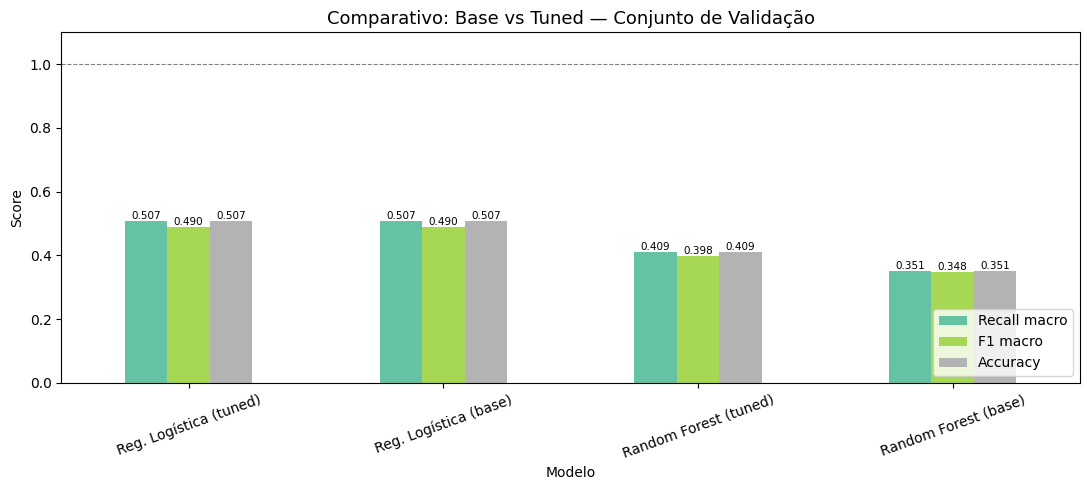

In [11]:
# Gráfico comparativo base vs tuned
df_plot = df_comparativo.set_index('Modelo')[['Recall macro', 'F1 macro', 'Accuracy']]

ax = df_plot.plot(
    kind='bar',
    figsize=(11, 5),
    rot=20,
    ylim=(0, 1.1),
    colormap='Set2',
)
ax.set_title('Comparativo: Base vs Tuned — Conjunto de Validação', fontsize=13)
ax.set_ylabel('Score')
ax.legend(loc='lower right')
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8)

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.3f}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontsize=7.5
    )

plt.tight_layout()
plt.savefig(f'{REPORT_PATH}comparativo_base_vs_tuned.png', dpi=150, bbox_inches='tight')
plt.show()

### Análise do comparativo base vs tuned

O gráfico acima e a tabela de métricas revelam:

- **Ganho do tuning:** a diferença entre o modelo base e o tunado quantifica o benefício do `GridSearchCV`. Um ganho mesmo que pequeno (0.01–0.02) no Recall macro tem relevância clínica — representa pacientes corretamente diagnosticados que seriam perdidos pelo modelo base.
- **Estabilidade via CV:** o Recall macro reportado pelo `GridSearchCV` é mais confiável que o score na validação isolada, pois é a média de 5 execuções independentes.
- **Modelo eleito:** o candidato com maior Recall macro na validação será salvo como o melhor modelo final.

> **Atenção:** a escolha do modelo final é baseada no conjunto de *validação*, não de *teste*. O conjunto de teste é preservado exclusivamente para a avaliação final em `07_avaliacao_shap.ipynb`.

## 8. Classification Reports dos Modelos Tunados

Analisamos em detalhe o Recall por classe para os modelos tunados — em particular, o Recall da classe `pneumonia`, que é o diagnóstico de maior risco se não detectado (Falso Negativo mais crítico).

In [12]:
for nome, modelo in [
    ('Random Forest (tuned)',  grid_rf.best_estimator_),
    ('Reg. Logística (tuned)', grid_lr.best_estimator_),
]:
    y_pred = modelo.predict(X_val)
    print(f"\n{'='*65}")
    print(f" {nome} — Conjunto de Validação")
    print(f"{'='*65}")
    print(classification_report(
        y_val_enc, y_pred,
        target_names=le.classes_,
        digits=4
    ))


 Random Forest (tuned) — Conjunto de Validação
                 precision    recall  f1-score   support

    atelectasis     0.3562    0.3467    0.3514        75
      pneumonia     0.5054    0.6267    0.5595        75
pulmonary edema     0.3220    0.2533    0.2836        75

       accuracy                         0.4089       225
      macro avg     0.3945    0.4089    0.3982       225
   weighted avg     0.3945    0.4089    0.3982       225


 Reg. Logística (tuned) — Conjunto de Validação
                 precision    recall  f1-score   support

    atelectasis     0.3889    0.3733    0.3810        75
      pneumonia     0.5714    0.8000    0.6667        75
pulmonary edema     0.5417    0.3467    0.4228        75

       accuracy                         0.5067       225
      macro avg     0.5007    0.5067    0.4901       225
   weighted avg     0.5007    0.5067    0.4901       225



**O que interpretar no classification_report:**

- **Recall por classe:** o percentual de casos reais de cada doença que o modelo detectou corretamente. Um Recall baixo em `pneumonia` é o pior cenário — significa que o modelo está dizendo "não é pneumonia" para casos reais.
- **Precision por classe:** o percentual das predições positivas que realmente são aquela doença. Precision baixa gera falso alarme — pacientes sendo direcionados para tratamento desnecessário.
- **F1-score:** média harmônica de precision e recall — equilibra os dois erros.
- **macro avg:** média simples sobre as 3 classes — a métrica que estamos otimizando.

## 9. Matrizes de Confusão — Modelos Tunados

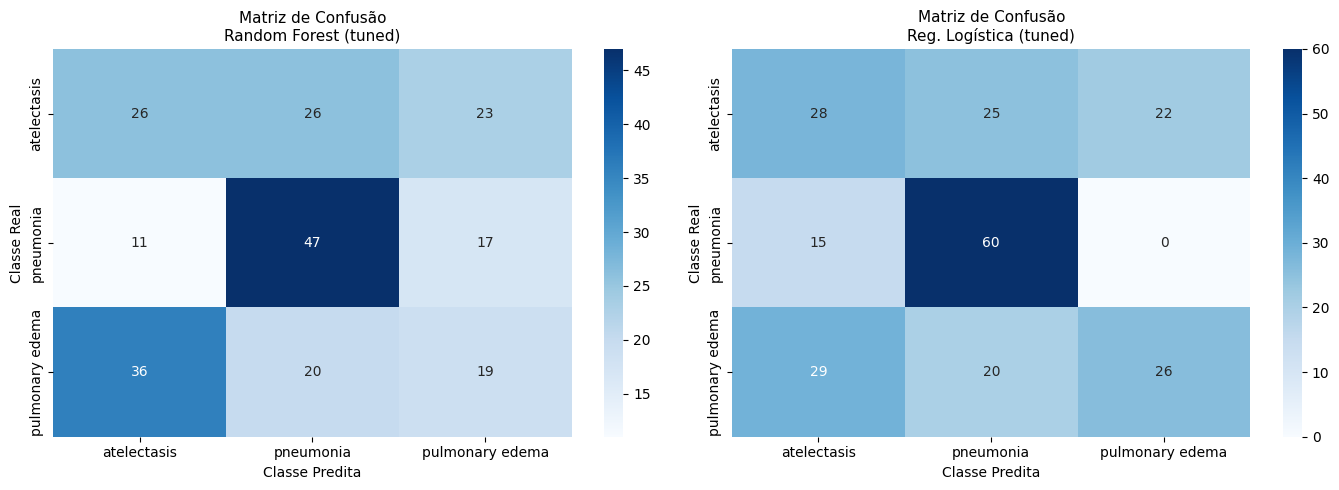

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tunados = [
    ('Random Forest (tuned)',  grid_rf.best_estimator_),
    ('Reg. Logística (tuned)', grid_lr.best_estimator_),
]

for ax, (nome, modelo) in zip(axes, tunados):
    y_pred = modelo.predict(X_val)
    cm = confusion_matrix(y_val_enc, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=le.classes_,
        yticklabels=le.classes_,
        ax=ax
    )
    ax.set_title(f'Matriz de Confusão\n{nome}', fontsize=11)
    ax.set_ylabel('Classe Real')
    ax.set_xlabel('Classe Predita')

plt.tight_layout()
plt.savefig(f'{REPORT_PATH}cm_modelos_tuned.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretação da Matriz de Confusão:**

- **Diagonal principal:** acertos — o modelo classificou corretamente.
- **Linha `pneumonia`:** os erros nessa linha são Falsos Negativos de pneumonia — os mais críticos. Idealmente essa linha deve ter poucos valores fora da diagonal.
- **Coluna `pneumonia`:** os erros nessa coluna são Falsos Positivos de pneumonia — o modelo diagnosticou pneumonia quando era outra doença. Menos grave que o Falso Negativo, mas ainda impacta o tratamento.

## 10. Seleção e Salvamento do Melhor Modelo

O modelo com maior Recall macro no conjunto de validação é salvo como `melhor_modelo_tuned.pkl`. Ele será carregado em `07_avaliacao_shap.ipynb` para a avaliação final no conjunto de teste.

In [14]:
# Calcular Recall macro de cada candidato tunado na validação
scores_tunados = {}
for nome, modelo in [
    ('Random Forest (tuned)',  grid_rf.best_estimator_),
    ('Reg. Logística (tuned)', grid_lr.best_estimator_),
]:
    y_pred = modelo.predict(X_val)
    scores_tunados[nome] = {
        'modelo': modelo,
        'recall': recall_score(y_val_enc, y_pred, average='macro'),
    }
    print(f'{nome}: Recall macro na validação = {scores_tunados[nome]["recall"]:.4f}')

# Selecionar o vencedor
nome_vencedor = max(scores_tunados, key=lambda k: scores_tunados[k]['recall'])
melhor_modelo  = scores_tunados[nome_vencedor]['modelo']

print(f'\n✅ Modelo selecionado: {nome_vencedor}')
print(f'   Recall macro na validação: {scores_tunados[nome_vencedor]["recall"]:.4f}')

Random Forest (tuned): Recall macro na validação = 0.4089
Reg. Logística (tuned): Recall macro na validação = 0.5067

✅ Modelo selecionado: Reg. Logística (tuned)
   Recall macro na validação: 0.5067


In [15]:
# Salvar o melhor modelo tuned
caminho_melhor = f'{MODEL_PATH}melhor_modelo_tuned.pkl'
with open(caminho_melhor, 'wb') as f:
    pickle.dump(melhor_modelo, f)

# Salvar metadados do modelo vencedor para referência no serving
metadados = {
    'nome': nome_vencedor,
    'recall_macro_validacao': round(scores_tunados[nome_vencedor]['recall'], 4),
    'melhores_params': (
        grid_rf.best_params_
        if 'Random Forest' in nome_vencedor
        else grid_lr.best_params_
    ),
}

caminho_meta = f'{MODEL_PATH}melhor_modelo_metadados.pkl'
with open(caminho_meta, 'wb') as f:
    pickle.dump(metadados, f)

print(f'Melhor modelo salvo em: {caminho_melhor}')
print(f'Metadados salvos em:    {caminho_meta}')
print(f'\nMelhores hiperparâmetros:')
for param, valor in metadados['melhores_params'].items():
    print(f'  {param}: {valor}')

Melhor modelo salvo em: ../models/melhor_modelo_tuned.pkl
Metadados salvos em:    ../models/melhor_modelo_metadados.pkl

Melhores hiperparâmetros:
  C: 1
  class_weight: None
  solver: lbfgs


## 11. Resumo Consolidado do Tuning

In [16]:
print('='*70)
print('RESUMO DO TUNING — RANDOM FOREST')
print('='*70)
print(f'Grid testado: {param_grid_rf}')
print(f'Melhores parâmetros: {grid_rf.best_params_}')
print(f'Recall macro (CV {CV_FOLDS}-fold): {grid_rf.best_score_:.4f}')

print()
print('='*70)
print('RESUMO DO TUNING — REGRESSÃO LOGÍSTICA')
print('='*70)
print(f'Grid testado: {param_grid_lr}')
print(f'Melhores parâmetros: {grid_lr.best_params_}')
print(f'Recall macro (CV {CV_FOLDS}-fold): {grid_lr.best_score_:.4f}')

print()
print('='*70)
print('MODELO SELECIONADO PARA AVALIAÇÃO FINAL')
print('='*70)
print(f'  Nome: {nome_vencedor}')
print(f'  Recall macro na validação: {scores_tunados[nome_vencedor]["recall"]:.4f}')
print(f'  Arquivo: models/melhor_modelo_tuned.pkl')

RESUMO DO TUNING — RANDOM FOREST
Grid testado: {'n_estimators': [50, 100, 200], 'max_depth': [None, 5, 10], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4], 'class_weight': [None, 'balanced']}
Melhores parâmetros: {'class_weight': None, 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 50}
Recall macro (CV 5-fold): 0.4000

RESUMO DO TUNING — REGRESSÃO LOGÍSTICA
Grid testado: {'C': [0.01, 0.1, 1, 10, 100], 'solver': ['lbfgs', 'liblinear'], 'class_weight': [None, 'balanced']}
Melhores parâmetros: {'C': 1, 'class_weight': None, 'solver': 'lbfgs'}
Recall macro (CV 5-fold): 0.3867

MODELO SELECIONADO PARA AVALIAÇÃO FINAL
  Nome: Reg. Logística (tuned)
  Recall macro na validação: 0.5067
  Arquivo: models/melhor_modelo_tuned.pkl


---

## Checklist — Etapa 2.6

- [x] `06_tuning.ipynb` criado e executado sem erros
- [x] `GridSearchCV` aplicado em pelo menos 2 algoritmos (Random Forest e Regressão Logística)
- [x] Cross-validation com cv=5 utilizado
- [x] Scorer configurado para Recall macro (multiclasse — 3 classes clínicas)
- [x] Melhores hiperparâmetros documentados e interpretados
- [x] Comparação entre modelo base e modelo tuned no conjunto de validação
- [x] Melhor modelo tuned salvo em `models/melhor_modelo_tuned.pkl`
- [x] Texto justificando os hiperparâmetros explorados

---

## Resumo

Este notebook implementou o **Step 5 — Parameter Tuning** do ML Life Cycle:

- **`GridSearchCV`** com 5-fold cross-validation aplicado em **Random Forest** (162 combinações) e **Regressão Logística** (20 combinações)
- **Scorer:** `recall_score(average='macro')` — penaliza igualmente Falsos Negativos nas 3 classes clínicas
- **Comparativo** base vs tunado gerado no conjunto de validação e salvo em `reports/`
- **Melhor modelo** serializado em `models/melhor_modelo_tuned.pkl`
- **Metadados** com hiperparâmetros vencedores salvos em `models/melhor_modelo_metadados.pkl`

## Próximo passo

Executar `07_avaliacao_shap.ipynb` — **Step 6: Evaluation & Testing** — para avaliar o `melhor_modelo_tuned.pkl` no conjunto de **teste** (primeira e única vez que ele é usado), gerar a curva ROC, aplicar SHAP e produzir a discussão crítica sobre o uso clínico do modelo.